<h2><center>Лабораторна робота №5: пошук по дереву<center></h2>

In [1]:
from TicTacToeNxN import TicTacToeNxN
from agent_mcts import MCTSAgent

from itertools import combinations
import random
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# random.seed(42)

temperatures = [0.25, 0.5, 1, 2, 4, 8, 16, 32]   # Можливі значення "температури"
games_per_combination = 50                       # Кількість ігор між кожною парою ШІ для збору статистики
num_temps = len(temperatures)
num_combinations = int(num_temps * (num_temps - 1) / 2)
win_matrix = np.zeros((num_temps, num_temps))    # Матриця статистики[]
np.fill_diagonal(win_matrix, 50)                 # Статистику проти ШІ тієї ж сили вважатимемо за 50%

for i, (t1, t2) in enumerate(combinations(temperatures, 2), start=1):
    print(f'\t({i}/{num_combinations}) Граємо {games_per_combination} матчів: X (t = {t1:.2f}) та O (t = {t2:.2f})')

    x_wins_count = 0
    o_wins_count = 0
    for i in range(games_per_combination):
        # Два агенти
        x_player = MCTSAgent(num_rounds=10, temperature=t1)
        o_player = MCTSAgent(num_rounds=10, temperature=t2)

        # Гра: хрестики-нулики 4х4 із довжиною виграшної послідовності в 3 токени, першість гравців чередується
        ttt4 = TicTacToeNxN(N=4, victory_len=3, starting_player='x' if i%2 else 'o')

        # Гра ШІ vs ШІ, результат
        game_cond = ttt4.agent_vs_agent(x_player=x_player, o_player=o_player)
        if 'WON' in game_cond:
            if game_cond.lower().startswith('x'):
                x_wins_count += 1
            else:
                o_wins_count += 1
    # Частоти перемог у %
    x_win_rate = (x_wins_count / games_per_combination) * 100
    o_win_rate = (o_wins_count / games_per_combination) * 100

    # Заповнюємо матрицю
    i = temperatures.index(t1)
    j = temperatures.index(t2)
    win_matrix[i, j] = x_win_rate  # t1 vs t2
    win_matrix[j, i] = o_win_rate  # t2 vs t1 

    print(f'X (t = {t1:.2f}) переміг {x_wins_count} раз ({x_win_rate:.2f}%)')
    print(f'O (t = {t2:.2f}) переміг {o_wins_count} раз ({o_win_rate:.2f}%)')
    
        

	(1/28) Граємо 50 матчів: X (t = 0.25) та O (t = 0.50)
X (t = 0.25) переміг 25 раз (50.00%)
O (t = 0.50) переміг 25 раз (50.00%)
	(2/28) Граємо 50 матчів: X (t = 0.25) та O (t = 1.00)
X (t = 0.25) переміг 21 раз (42.00%)
O (t = 1.00) переміг 29 раз (58.00%)
	(3/28) Граємо 50 матчів: X (t = 0.25) та O (t = 2.00)
X (t = 0.25) переміг 17 раз (34.00%)
O (t = 2.00) переміг 33 раз (66.00%)
	(4/28) Граємо 50 матчів: X (t = 0.25) та O (t = 4.00)
X (t = 0.25) переміг 26 раз (52.00%)
O (t = 4.00) переміг 23 раз (46.00%)
	(5/28) Граємо 50 матчів: X (t = 0.25) та O (t = 8.00)
X (t = 0.25) переміг 24 раз (48.00%)
O (t = 8.00) переміг 26 раз (52.00%)
	(6/28) Граємо 50 матчів: X (t = 0.25) та O (t = 16.00)
X (t = 0.25) переміг 22 раз (44.00%)
O (t = 16.00) переміг 28 раз (56.00%)
	(7/28) Граємо 50 матчів: X (t = 0.25) та O (t = 32.00)
X (t = 0.25) переміг 29 раз (58.00%)
O (t = 32.00) переміг 21 раз (42.00%)
	(8/28) Граємо 50 матчів: X (t = 0.50) та O (t = 1.00)
X (t = 0.50) переміг 22 раз (44.00%)
O

In [8]:
# Середні частоти перемог кожної температури проти всіх інших
avg_win_rates = []
for i in range(num_temps):
    # Сума частот перемог проти всіх інших / (num_temps - 1)
    sum_against_others = np.sum(win_matrix[i, :]) - win_matrix[i, i]
    avg = sum_against_others / (num_temps - 1)
    avg_win_rates.append(avg)

# Температура із найбільшою середньою частотою перемог
best_idx = np.argmax(avg_win_rates)
best_temp = temperatures[best_idx]
print(f'Найсильніший в середньому ШІ: із температурою t = {best_temp:.2f}, середня частота перемог: {avg_win_rates[best_idx]:.2f}%')

# Всі середні частоти перемог по температурам
for t, avg in zip(temperatures, avg_win_rates):
    print(f'ШІ з температурою t = {t:.1f}: середня частота перемог: {avg:.2f}%')

Найсильніший в середньому ШІ: із температурою t = 2.00, середня частота перемог: 54.29%
ШІ з температурою t = 0.2: середня частота перемог: 46.86%
ШІ з температурою t = 0.5: середня частота перемог: 44.00%
ШІ з температурою t = 1.0: середня частота перемог: 52.00%
ШІ з температурою t = 2.0: середня частота перемог: 54.29%
ШІ з температурою t = 4.0: середня частота перемог: 53.14%
ШІ з температурою t = 8.0: середня частота перемог: 52.86%
ШІ з температурою t = 16.0: середня частота перемог: 49.71%
ШІ з температурою t = 32.0: середня частота перемог: 44.00%


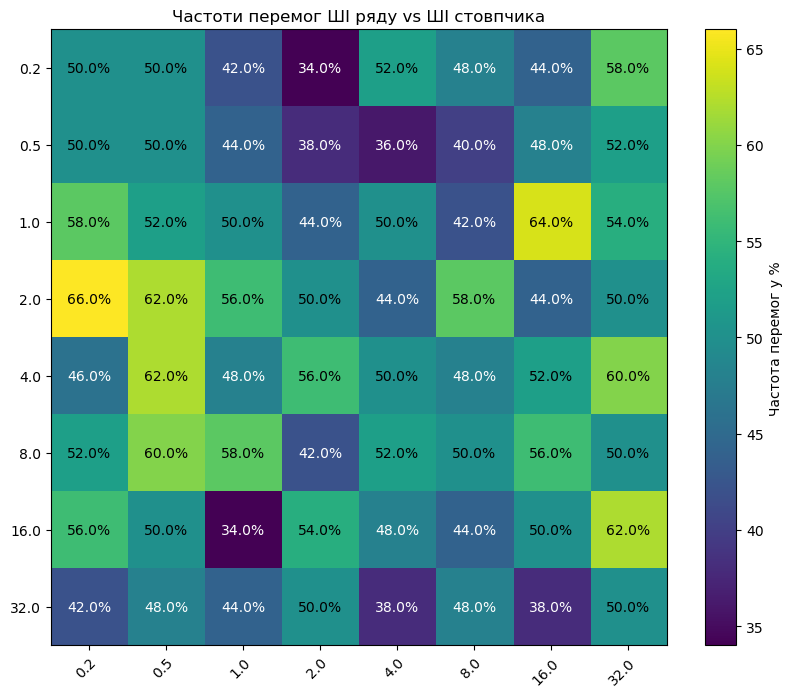

In [9]:
# Відображення heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(win_matrix, cmap='viridis')

ax.set_xticks(np.arange(num_temps))
ax.set_yticks(np.arange(num_temps))
ax.set_xticklabels([f'{t:.1f}' for t in temperatures])
ax.set_yticklabels([f'{t:.1f}' for t in temperatures])

# Поворот підписів осі х для зручності
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Підписи частот
for i in range(num_temps):
    for j in range(num_temps):
        text = ax.text(j, i, f'{win_matrix[i, j]:.1f}%', ha="center", va="center", color="w" if win_matrix[i, j] < 50 else "black")

ax.set_title('Частоти перемог ШІ ряду vs ШІ стовпчика')
fig.colorbar(im, ax=ax, label='Частота перемог у %')
plt.show()